Step 1 — Open historical precipitation

In [5]:
import xarray as xr
import numpy as np

ds = xr.open_dataset(
    "../Canesm5/pr/hist/pr_station.nc",
    decode_times=True,
    use_cftime=True
)

pr = ds['pr'].squeeze() * 86400  # convert to mm/day

Step 2 — Define wet days (≥1 mm)

In [6]:
wet_days = pr.where(pr >= 1)

Step 3 — Calculate 95th percentile (reference period)

In [7]:
baseline = wet_days.sel(time=slice("1980", "2014"))
p95 = baseline.quantile(0.95)

Step 4 — Compute R95p annually

In [8]:
r95p = pr.where(pr > p95)
r95p_annual = r95p.resample(time="Y").sum()

<string>:7: FutureWarning: 'Y' is deprecated and will be removed in a future version. Please use 'YE' instead of 'Y'.


Convert for plotting:

In [9]:
r95p_pd = r95p_annual.to_pandas()
r95p_pd.index = r95p_pd.index.year
print(r95p_pd.head())

1850     0.000000
1851    69.001358
1852    24.721066
1853    78.352661
1854    51.703342
Name: pr, dtype: float32


now we have annual extreme precipitation totals.

CONSECUTIVE DRY DAYS (CDD)
Definition

CDD = Maximum number of consecutive days with precipitation < 1 mm per year.

In [10]:
dry = pr < 1

In [11]:
#function to compute max drt day
def max_consecutive(arr):
    max_run = run = 0
    for val in arr:
        if val:
            run += 1
            max_run = max(max_run, run)
        else:
            run = 0
    return max_run

In [13]:
def max_consecutive(arr, axis=None):
    arr = np.asarray(arr)
    
    if axis is not None:
        arr = np.moveaxis(arr, axis, 0)
        results = []
        for year_data in arr:
            max_run = run = 0
            for val in year_data:
                if val:
                    run += 1
                    max_run = max(max_run, run)
                else:
                    run = 0
            results.append(max_run)
        return np.array(results)
    
    else:
        max_run = run = 0
        for val in arr:
            if val:
                run += 1
                max_run = max(max_run, run)
            else:
                run = 0
        return max_run

In [17]:
print(pr.dims)

('time',)


In [18]:
pr = pr * 86400

In [19]:
pr_series = pr.to_pandas()

In [20]:
print(type(pr_series))

<class 'pandas.core.series.Series'>


In [21]:
import numpy as np

def max_consecutive_dry(series):
    max_run = run = 0
    for val in series:
        if val < 1:
            run += 1
            max_run = max(max_run, run)
        else:
            run = 0
    return max_run

# Apply per year
cdd = pr_series.groupby(pr_series.index.year).apply(max_consecutive_dry)

print(cdd.head())

1850    17
1851    19
1852    37
1853    22
1854    37
Name: pr, dtype: int64


In [22]:
#final clean CDD script

import xarray as xr
import pandas as pd
import numpy as np

ds = xr.open_dataset(
    "../Canesm5/pr/hist/pr_station.nc",
    decode_times=True,
    use_cftime=True
)

pr = ds['pr'].squeeze() * 86400
pr_series = pr.to_pandas()

def max_consecutive_dry(series):
    max_run = run = 0
    for val in series:
        if val < 1:
            run += 1
            max_run = max(max_run, run)
        else:
            run = 0
    return max_run

cdd = pr_series.groupby(pr_series.index.year).apply(max_consecutive_dry)

print(cdd.head())

1850     88
1851    160
1852     87
1853    136
1854    120
Name: pr, dtype: int64


In [23]:
cdd

1850     88
1851    160
1852     87
1853    136
1854    120
       ... 
2010    114
2011    102
2012    117
2013    132
2014     86
Name: pr, Length: 165, dtype: int64

In [24]:
from scipy.stats import kendalltau
import numpy as np

years = cdd.index.values
values = cdd.values

tau, p_value = kendalltau(years, values)

# Sen's slope
slope = np.median([
    (values[j] - values[i]) / (years[j] - years[i])
    for i in range(len(values))
    for j in range(i+1, len(values))
])

print("Trend direction:", "Increasing" if slope > 0 else "Decreasing")
print("Sen slope (days/year):", slope)
print("p-value:", p_value)

Trend direction: Increasing
Sen slope (days/year): 0.017778128950695322
p-value: 0.8172189757503481


Historical vs SSP585 CDD Comparison

In [26]:
import xarray as xr

ssp = xr.open_dataset(
    "../Canesm5/pr/ssp858/pr_day_CanESM5_ssp585_r1i1p1f1_gn_20150101-21001231.nc",
    decode_times=True,
    use_cftime=True
)

print(ssp)

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 31390, bnds: 2, lat: 64, lon: 128)
Coordinates:
  * time       (time) object 251kB 2015-01-01 12:00:00 ... 2100-12-31 12:00:00
  * lat        (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
  * lon        (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 351.6 354.4 357.2
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 502kB ...
    lat_bnds   (lat, bnds) float64 1kB ...
    lon_bnds   (lon, bnds) float64 2kB ...
    pr         (time, lat, lon) float32 1GB ...
Attributes: (12/53)
    CCCma_model_hash:            1f91f92cb6d607391f44831504025d32fc44faa1
    CCCma_parent_runid:          rc3.1-his01
    CCCma_pycmor_hash:           33c30511acc319a98240633965a04ca99c26427e
    CCCma_runid:                 rc3.1-s8501
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   2015:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/b72

In [27]:
# Example coordinates of Saidu Sharif
lat_station = 35.0
lon_station = 72.4

pr_ssp_station = ssp['pr'].sel(
    lat=lat_station, lon=lon_station, method='nearest'
) * 86400  # convert to mm/day

In [28]:
pr_ssp_series = pr_ssp_station.to_pandas()
print(pr_ssp_series.head())

time
2015-01-01 12:00:00    0.000000
2015-01-02 12:00:00    0.000000
2015-01-03 12:00:00    0.000000
2015-01-04 12:00:00    0.000000
2015-01-05 12:00:00    0.000403
Name: pr, dtype: float32


In [29]:
cdd_ssp = pr_ssp_series.groupby(pr_ssp_series.index.year).apply(max_consecutive_dry)

In [30]:
hist_mean = cdd.loc[1980:2014].mean()
future_mean = cdd_ssp.loc[2070:2100].mean()

change = future_mean - hist_mean

print("Historical CDD:", hist_mean)
print("Future CDD:", future_mean)
print("Change (days):", change)

Historical CDD: 140.02857142857144
Future CDD: 96.45161290322581
Change (days): -43.57695852534563


Temperature Extreme Index — TX90p

Definition (ETCCDI):

TX90p = Percentage of days when daily Tmax > 90th percentile (baseline 1980–2014)

In [33]:
import xarray as xr

ds_t = xr.open_dataset(
    "..//Canesm5/tasmax/hist/tasmax_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc",
    decode_times=True,
    use_cftime=True
)

print(ds_t)

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 60225, bnds: 2, lat: 64, lon: 128)
Coordinates:
  * time       (time) object 482kB 1850-01-01 12:00:00 ... 2014-12-31 12:00:00
  * lat        (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
  * lon        (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 351.6 354.4 357.2
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 964kB ...
    lat_bnds   (lat, bnds) float64 1kB ...
    lon_bnds   (lon, bnds) float64 2kB ...
    tasmax     (time, lat, lon) float32 2GB ...
Attributes: (12/53)
    CCCma_model_hash:            3dedf95315d603326fde4f5340dc0519d80d10c0
    CCCma_parent_runid:          rc3-pictrl
    CCCma_pycmor_hash:           33c30511acc319a98240633965a04ca99c26427e
    CCCma_runid:                 rc3.1-his01
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   1850:01:01:00
    ...                          ...
    tracking_id:    

In [34]:
tas_station = ds_t['tasmax'].sel(
    lat=35.0,
    lon=72.4,
    method='nearest'
) - 273.15  # Convert K → °C

In [35]:
tas_series = tas_station.to_pandas()
print(tas_series.head())

time
1850-01-01 12:00:00   -4.289185
1850-01-02 12:00:00   -3.052155
1850-01-03 12:00:00   -4.105286
1850-01-04 12:00:00   -1.101837
1850-01-05 12:00:00   -8.647644
Name: tasmax, dtype: float32


In [36]:
tas_annual = tas_series.groupby(tas_series.index.year).mean()
print(tas_annual.head())

1850     8.565189
1851    10.813749
1852     9.199486
1853    11.414774
1854    11.420600
Name: tasmax, dtype: float32


In [37]:
baseline = tas_series.loc["1980":"2014"]
p90 = baseline.quantile(0.90)

In [38]:
tx90 = tas_series > p90
tx90_annual = tx90.groupby(tx90.index.year).mean() * 100

print(tx90_annual.head())

1850    0.000000
1851    1.917808
1852    0.821918
1853    7.671233
1854    2.739726
Name: tasmax, dtype: float64


In [39]:
years = tx90_annual.index.values
values = tx90_annual.values

tau, p_value = kendalltau(years, values)

slope = np.median([
    (values[j] - values[i]) / (years[j] - years[i])
    for i in range(len(values))
    for j in range(i+1, len(values))
])

print("TX90p trend (% per year):", slope)
print("p-value:", p_value)

TX90p trend (% per year): 0.03842983466860725
p-value: 3.304116509069056e-11


Full Quantile Mapping Bias Correction

In [40]:
import pandas as pd

obs = pd.read_csv("../station_data/tasmax_pr_1980-2024.csv")
obs['time'] = pd.to_datetime(obs['time'])
obs = obs.set_index('time')

obs_pr = obs['pr']

In [43]:
import pandas as pd

# Load observed
obs = pd.read_csv("../station_data/tasmax_pr_1980-2024.csv")
obs['time'] = pd.to_datetime(obs['time'])
obs = obs.set_index('time')

# Sort the index
obs = obs.sort_index()

obs_pr = obs['pr']

In [44]:
pr_series = pr_series.sort_index()

In [45]:
obs_hist = obs_pr.loc["1980":"2014"]
model_hist = pr_series.loc["1980":"2014"]

In [46]:
def quantile_mapping(model_series, model_hist, obs_hist):
    corrected = []

    model_sorted = np.sort(model_hist)
    obs_sorted = np.sort(obs_hist)

    for value in model_series:
        q = np.searchsorted(model_sorted, value) / len(model_sorted)
        q = min(max(q, 0), 0.999)
        corrected_value = np.quantile(obs_sorted, q)
        corrected.append(corrected_value)

    return np.array(corrected)

In [47]:
pr_ssp_corrected = quantile_mapping(
    pr_ssp_series,
    model_hist,
    obs_hist
)

pr_ssp_corrected = pd.Series(
    pr_ssp_corrected,
    index=pr_ssp_series.index
)

Extreme Precipitation — R95p

In [48]:
import xarray as xr

# Open historical precipitation NetCDF
ds = xr.open_dataset(
    "../Canesm5/pr/hist/pr_station.nc",
    decode_times=True,
    use_cftime=True
)

# Select your station (Saidu Sharif example coordinates)
lat_station = 35.0
lon_station = 72.4
pr = ds['pr'].sel(lat=lat_station, lon=lon_station, method='nearest') * 86400  # convert to mm/day

In [49]:
wet_days = pr.where(pr >= 1)

In [50]:
baseline = wet_days.sel(time=slice("1980", "2014"))
p95 = baseline.quantile(0.95)

In [51]:
r95p = wet_days.where(wet_days > p95)
r95p_annual = r95p.resample(time="Y").sum()

<string>:7: FutureWarning: 'Y' is deprecated and will be removed in a future version. Please use 'YE' instead of 'Y'.


In [52]:
r95p_series = r95p_annual.to_pandas()
r95p_series.index = r95p_series.index.year
print(r95p_series.head())

1850     0.000000
1851    69.001358
1852    24.721066
1853    78.352661
1854    51.703342
Name: pr, dtype: float32


Goal: Compute the maximum number of consecutive days with precipitation < 1 mm per year.

In [53]:
# Convert to pandas Series
pr_series = pr.to_pandas()

# Ensure the index is sorted
pr_series = pr_series.sort_index()

In [55]:
def max_consecutive_dry(series, threshold=1.0):
    """
    series: pandas Series of daily precipitation
    threshold: maximum rainfall to be considered a 'dry' day
    """
    max_run = run = 0
    for val in series:
        if val < threshold:
            run += 1
            max_run = max(max_run, run)
        else:
            run = 0
    return max_run

In [56]:
# Group by year and apply the function
cdd = pr_series.groupby(pr_series.index.year).apply(max_consecutive_dry)

print(cdd.head())

1850     88
1851    160
1852     87
1853    136
1854    120
Name: pr, dtype: int64


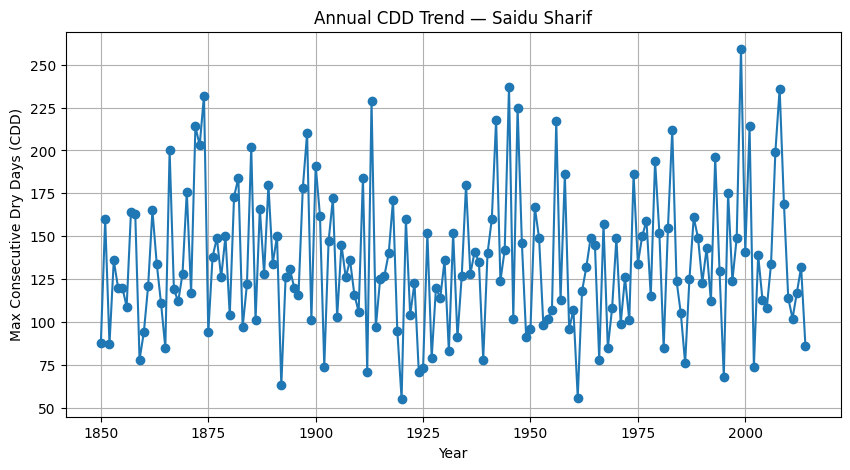

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(cdd.index, cdd.values, marker='o', linestyle='-')
plt.xlabel("Year")
plt.ylabel("Max Consecutive Dry Days (CDD)")
plt.title("Annual CDD Trend — Saidu Sharif")
plt.grid(True)
plt.show()

In [58]:
cdd

1850     88
1851    160
1852     87
1853    136
1854    120
       ... 
2010    114
2011    102
2012    117
2013    132
2014     86
Name: pr, Length: 165, dtype: int64

In [59]:
from scipy.stats import kendalltau
import numpy as np

In [60]:
years = cdd.index.values
values = cdd.values

In [61]:
tau, p_value = kendalltau(years, values)

print("Mann-Kendall Tau:", tau)
print("p-value:", p_value)

Mann-Kendall Tau: 0.012160824031117925
p-value: 0.8172189757503481


In [62]:
slope = np.median([
    (values[j] - values[i]) / (years[j] - years[i])
    for i in range(len(values))
    for j in range(i+1, len(values))
])

print("Sen's slope (days/year):", slope)

Sen's slope (days/year): 0.017778128950695322


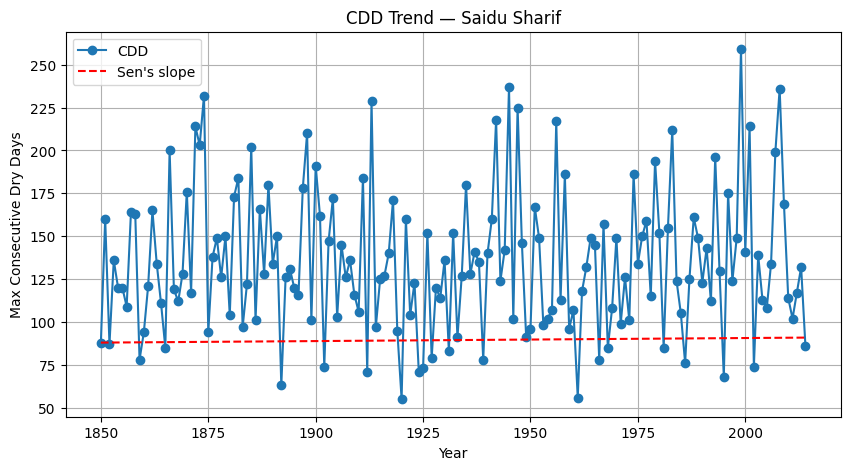

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(years, values, marker='o', linestyle='-', label='CDD')
plt.plot(years, values[0] + slope*(years - years[0]), 'r--', label="Sen's slope")
plt.xlabel("Year")
plt.ylabel("Max Consecutive Dry Days")
plt.title("CDD Trend — Saidu Sharif")
plt.legend()
plt.grid(True)
plt.show()

Historical vs SSP comparison for CDD.

In [64]:
import xarray as xr

# Open SSP precipitation
ssp = xr.open_dataset(
    "../Canesm5/pr/ssp858/pr_day_CanESM5_ssp585_r1i1p1f1_gn_20150101-21001231.nc",
    decode_times=True,
    use_cftime=True
)

# Select Saidu Sharif coordinates
lat_station = 35.0
lon_station = 72.4
pr_ssp = ssp['pr'].sel(lat=lat_station, lon=lon_station, method='nearest') * 86400  # mm/day

# Convert to pandas Series
pr_ssp_series = pr_ssp.to_pandas().sort_index()

In [65]:
def max_consecutive_dry(series, threshold=1.0):
    max_run = run = 0
    for val in series:
        if val < threshold:
            run += 1
            max_run = max(max_run, run)
        else:
            run = 0
    return max_run

# Group by year
cdd_ssp = pr_ssp_series.groupby(pr_ssp_series.index.year).apply(max_consecutive_dry)

In [66]:
hist_cdd = cdd.loc[1980:2014]
future_cdd = cdd_ssp.loc[2070:2100]

# Compute means
hist_mean = hist_cdd.mean()
future_mean = future_cdd.mean()
change = future_mean - hist_mean

print("Historical CDD (1980-2014) mean:", hist_mean)
print("Future CDD (2070-2100) mean:", future_mean)
print("Projected change (days):", change)

Historical CDD (1980-2014) mean: 140.02857142857144
Future CDD (2070-2100) mean: 96.45161290322581
Projected change (days): -43.57695852534563


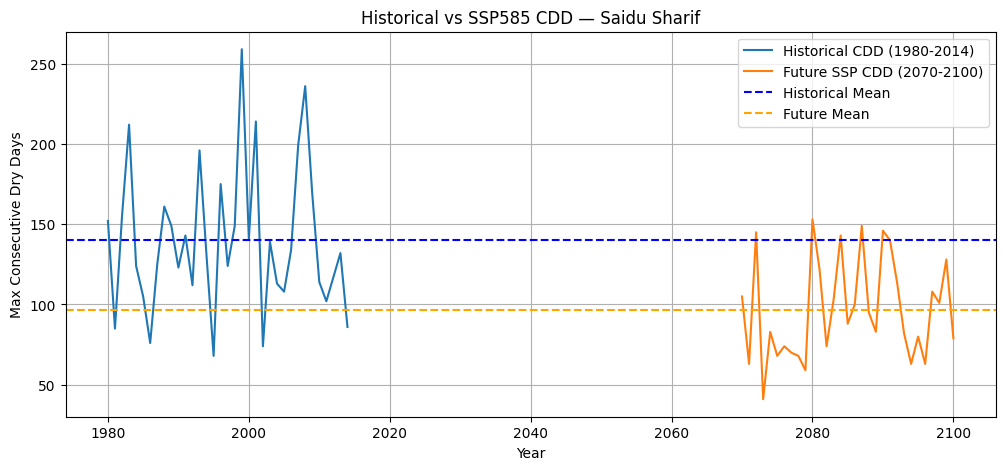

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(hist_cdd.index, hist_cdd.values, label="Historical CDD (1980-2014)")
plt.plot(future_cdd.index, future_cdd.values, label="Future SSP CDD (2070-2100)")
plt.axhline(hist_mean, color='blue', linestyle='--', label="Historical Mean")
plt.axhline(future_mean, color='orange', linestyle='--', label="Future Mean")
plt.xlabel("Year")
plt.ylabel("Max Consecutive Dry Days")
plt.title("Historical vs SSP585 CDD — Saidu Sharif")
plt.legend()
plt.grid(True)
plt.show()

Temperature Extreme Index (TX90p)

In [70]:
import xarray as xr

# Load historical tasmax
ds_t = xr.open_dataset(
    "..//Canesm5/tasmax/hist/tasmax_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc",
    decode_times=True,
    use_cftime=True
)

# Select Saidu Sharif coordinates
lat_station = 35.0
lon_station = 72.4
tas = ds_t['tasmax'].sel(lat=lat_station, lon=lon_station, method='nearest') - 273.15  # Convert K -> °C

# Convert to pandas series
tas_series = tas.to_pandas().sort_index()

In [71]:
baseline = tas_series.loc["1980":"2014"]
p90 = baseline.quantile(0.90)
print("90th percentile (°C):", p90)

90th percentile (°C): 28.70235595703125


In [72]:
# Boolean series: 1 if above 90th percentile, 0 otherwise
tx90_bool = tas_series > p90

# Annual mean * 100 → % of days
tx90_annual = tx90_bool.groupby(tx90_bool.index.year).mean() * 100
print(tx90_annual.head())

1850    0.000000
1851    1.917808
1852    0.821918
1853    7.671233
1854    2.739726
Name: tasmax, dtype: float64


In [73]:
from scipy.stats import kendalltau
import numpy as np

years = tx90_annual.index.values
values = tx90_annual.values

tau, p_value = kendalltau(years, values)

# Sen's slope (% per year)
slope = np.median([
    (values[j] - values[i]) / (years[j] - years[i])
    for i in range(len(values))
    for j in range(i+1, len(values))
])

print("TX90p trend (% per year):", slope)
print("p-value:", p_value)

TX90p trend (% per year): 0.03842983466860725
p-value: 3.304116509069056e-11


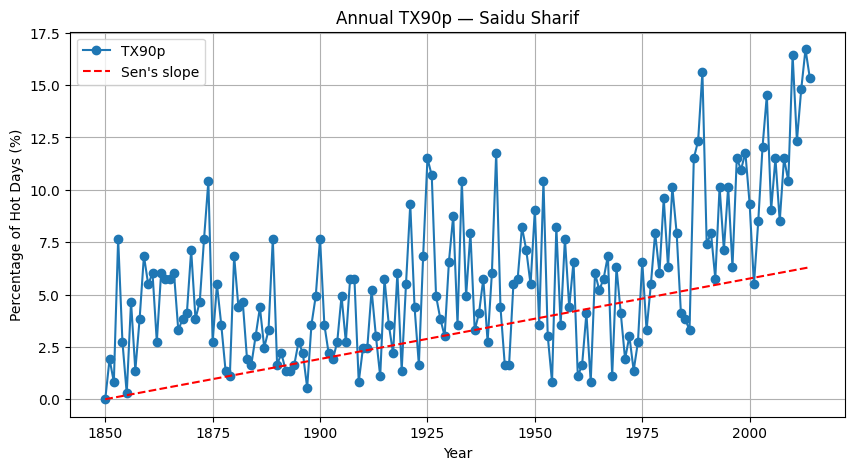

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(years, values, marker='o', linestyle='-', label="TX90p")
plt.plot(years, values[0] + slope*(years - years[0]), 'r--', label="Sen's slope")
plt.xlabel("Year")
plt.ylabel("Percentage of Hot Days (%)")
plt.title("Annual TX90p — Saidu Sharif")
plt.legend()
plt.grid(True)
plt.show()

Full Quantile Mapping (Bias Correction)

In [75]:
import pandas as pd

# Load CSV
obs = pd.read_csv("../station_data/tasmax_pr_1980-2024.csv")

# Convert to datetime and set as index
obs['time'] = pd.to_datetime(obs['time'])
obs = obs.set_index('time').sort_index()

# Select precipitation
obs_pr = obs['pr']

In [76]:
# Historical model (already extracted as pr_series)
model_hist = pr_series.loc["1980":"2014"]
obs_hist = obs_pr.loc["1980":"2014"]

In [77]:
import numpy as np

def quantile_mapping(model_series, model_hist, obs_hist):
    """
    model_series: future model data (pandas Series)
    model_hist: historical model data for baseline
    obs_hist: observed data for baseline
    """
    corrected = []

    # Sort baseline data
    model_sorted = np.sort(model_hist)
    obs_sorted = np.sort(obs_hist)

    for value in model_series:
        # Find the quantile of model value in historical model
        q = np.searchsorted(model_sorted, value) / len(model_sorted)
        q = min(max(q, 0), 0.999)  # clip to avoid edge issues

        # Map quantile to observed
        corrected_value = np.quantile(obs_sorted, q)
        corrected.append(corrected_value)

    return pd.Series(corrected, index=model_series.index)

In [78]:
# Future SSP precipitation (station point)
pr_ssp_corrected = quantile_mapping(pr_ssp_series, model_hist, obs_hist)

# Inspect
print(pr_ssp_corrected.head())

time
2015-01-01 12:00:00   -100.0
2015-01-02 12:00:00   -100.0
2015-01-03 12:00:00   -100.0
2015-01-04 12:00:00   -100.0
2015-01-05 12:00:00      0.0
dtype: float64


In [80]:
import pandas as pd

# Convert xarray DataArray to pandas Series with proper datetime
def xr_to_series(dataarray):
    """
    Convert xarray.DataArray with cftime time axis to pandas.Series
    """
    times = pd.to_datetime(dataarray['time'].values.astype(str))
    series = pd.Series(dataarray.values, index=times)
    return series.sort_index()

In [82]:
pr_ssp_series = xr_to_series(pr_ssp)

In [84]:
obs_pr_series = obs_pr.sort_index()  # already pandas, just sort

In [85]:
print(type(pr_ssp_series.index[0]))

<class 'pandas._libs.tslibs.timestamps.Timestamp'>


Raw SSP precipitation:
2015-01-01 12:00:00    0.000000
2015-01-02 12:00:00    0.000000
2015-01-03 12:00:00    0.000000
2015-01-04 12:00:00    0.000000
2015-01-05 12:00:00    0.000403
dtype: float32

Bias-corrected SSP precipitation:
2015-01-01 12:00:00   -100.0
2015-01-02 12:00:00   -100.0
2015-01-03 12:00:00   -100.0
2015-01-04 12:00:00   -100.0
2015-01-05 12:00:00      0.0
dtype: float64


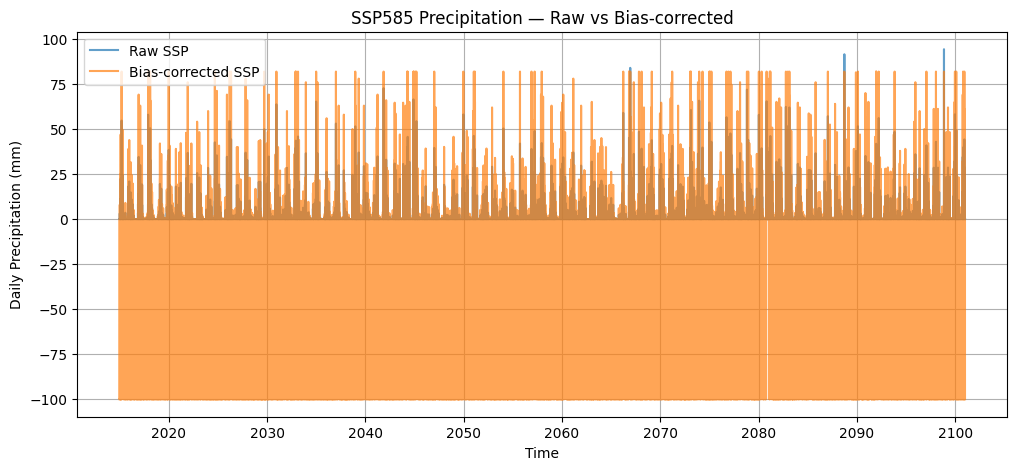

In [86]:
# -------------------------------
# Full Quantile Mapping (Bias Correction) — Precipitation
# -------------------------------

import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Step 1: Define helper to convert cftime to pandas Series
# -------------------------------
def xr_to_series(dataarray):
    """
    Convert xarray.DataArray with cftime time axis to pandas.Series
    """
    times = pd.to_datetime(dataarray['time'].values.astype(str))
    series = pd.Series(dataarray.values, index=times)
    return series.sort_index()

# -------------------------------
# Step 2: Load observed station data
# -------------------------------
obs = pd.read_csv("../station_data/tasmax_pr_1980-2024.csv")
obs['time'] = pd.to_datetime(obs['time'])
obs = obs.set_index('time').sort_index()

obs_pr = obs['pr']  # daily precipitation

# -------------------------------
# Step 3: Load historical model data
# -------------------------------
ds_hist = xr.open_dataset("../Canesm5/pr/hist/pr_station.nc", decode_times=True, use_cftime=True)

# Select station grid point (Saidu Sharif example)
lat_station = 35.0
lon_station = 72.4
pr_hist = ds_hist['pr'].sel(lat=lat_station, lon=lon_station, method='nearest') * 86400  # mm/day

pr_hist_series = xr_to_series(pr_hist)

# -------------------------------
# Step 4: Load future SSP scenario
# -------------------------------
ds_ssp = xr.open_dataset("../Canesm5/pr/ssp858/pr_day_CanESM5_ssp585_r1i1p1f1_gn_20150101-21001231.nc",
                         decode_times=True, use_cftime=True)

pr_ssp = ds_ssp['pr'].sel(lat=lat_station, lon=lon_station, method='nearest') * 86400
pr_ssp_series = xr_to_series(pr_ssp)

# -------------------------------
# Step 5: Select baseline period for quantile mapping (1980-2014)
# -------------------------------
model_hist = pr_hist_series.loc["1980":"2014"]
obs_hist = obs_pr.loc["1980":"2014"]

# -------------------------------
# Step 6: Define Quantile Mapping function
# -------------------------------
def quantile_mapping(model_series, model_hist, obs_hist):
    """
    Apply quantile mapping bias correction
    """
    corrected = []

    # Sort baseline data
    model_sorted = np.sort(model_hist)
    obs_sorted = np.sort(obs_hist)

    for value in model_series:
        # Find quantile of model value in historical model
        q = np.searchsorted(model_sorted, value) / len(model_sorted)
        q = min(max(q, 0), 0.999)  # clip to avoid edge issues

        # Map quantile to observed
        corrected_value = np.quantile(obs_sorted, q)
        corrected.append(corrected_value)

    return pd.Series(corrected, index=model_series.index)

# -------------------------------
# Step 7: Apply Quantile Mapping to SSP series
# -------------------------------
pr_ssp_corrected = quantile_mapping(pr_ssp_series, model_hist, obs_hist)

# -------------------------------
# Step 8: Inspect results
# -------------------------------
print("Raw SSP precipitation:")
print(pr_ssp_series.head())

print("\nBias-corrected SSP precipitation:")
print(pr_ssp_corrected.head())

# -------------------------------
# Step 9: Optional plot
# -------------------------------
plt.figure(figsize=(12,5))
plt.plot(pr_ssp_series.index, pr_ssp_series.values, label="Raw SSP", alpha=0.7)
plt.plot(pr_ssp_corrected.index, pr_ssp_corrected.values, label="Bias-corrected SSP", alpha=0.7)
plt.xlabel("Time")
plt.ylabel("Daily Precipitation (mm)")
plt.title("SSP585 Precipitation — Raw vs Bias-corrected")
plt.legend()
plt.grid(True)
plt.show()